In [12]:
import json
import os
from collections import defaultdict
import traceback
from difflib import SequenceMatcher
import argparse

import fitz
from fitz import Rect
from PIL import Image
import xml.etree.ElementTree as ET
from xml.dom import minidom
# import editdistance
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pdf2image import convert_from_path
from PyPDF2 import PdfFileReader
import json
import numpy as np
import pdf2image
from os import path
from PIL import Image
from PIL import ImageFont, ImageDraw
import copy
import re
import ast
import jsonlines
import pandas as pd

In [35]:
from ultralytics import YOLO

ImportError: cannot import name 'get_host' from 'urllib3.util.url' (c:\Users\bom\miniconda3\envs\env1\lib\site-packages\urllib3\util\url.py)

In [9]:
data_fintabnet_path =  "D:/fintabnet/fintabnet/"
subdir = "test"
structure_filename  = "FinTabNet_1.0.0_cell_" + subdir + ".jsonl"
detection_filename = "FinTabNet_1.0.0_table_" + subdir +  ".jsonl"
structure_filepath = os.path.join(data_fintabnet_path, structure_filename)
detection_filepath = os.path.join(data_fintabnet_path, detection_filename)
print(f'detection_filepath :{structure_filepath}')
with open(structure_filepath, "r") as f:
    structure_lines = f.readlines()

detection_filepath :D:/fintabnet/fintabnet/FinTabNet_1.0.0_cell_test.jsonl


In [10]:
i = 0
data_frame = {}
with jsonlines.open(detection_filepath,'r') as f:
# with jsonlines.open('FinTabNet_1.0.0_table_example.jsonl','r') as f:
    for data in f:
        # if i > 30000 :
        #     break
        file_name = data['filename']
        print(f'file_name :{file_name}')
        if file_name in data_frame:
            box     = data['bbox']
            data_frame[file_name].append(box) 
        else:
            box = data['bbox']  
            update = {file_name : [box]}
            data_frame.update(**update)
        i = i +1 

file_name :HAL/2009/page_77.pdf
file_name :HAL/2005/page_92.pdf
file_name :HAL/2014/page_40.pdf
file_name :HAL/2009/page_49.pdf
file_name :HAL/2015/page_42.pdf
file_name :HAL/2008/page_78.pdf
file_name :HAL/2017/page_82.pdf
file_name :HAL/2007/page_61.pdf
file_name :HAL/2009/page_91.pdf
file_name :HAL/2007/page_88.pdf
file_name :HAL/2017/page_81.pdf
file_name :HAL/2009/page_88.pdf
file_name :HAL/2014/page_82.pdf
file_name :HAL/2008/page_99.pdf
file_name :HAL/2005/page_109.pdf
file_name :HAL/2017/page_38.pdf
file_name :HAL/2009/page_105.pdf
file_name :HAL/2015/page_87.pdf
file_name :HAL/2016/page_74.pdf
file_name :HAL/2009/page_80.pdf
file_name :HAL/2016/page_74.pdf
file_name :HAL/2017/page_72.pdf
file_name :HAL/2007/page_27.pdf
file_name :HAL/2014/page_91.pdf
file_name :HAL/2014/page_82.pdf
file_name :HAL/2016/page_59.pdf
file_name :HAL/2007/page_98.pdf
file_name :HAL/2016/page_39.pdf
file_name :HAL/2009/page_77.pdf
file_name :HAL/2007/page_43.pdf
file_name :HAL/2009/page_92.pdf
file_n

In [13]:
final_data = pd.DataFrame(data_frame.items())
final_data.to_csv("YOLO_data.csv", index=False)
row, col  = final_data.shape
row

5903

In [5]:
def xyxy_to_yolo( x_min, y_min, x_max, y_max, image_width, image_height):
    """
    Chuyển đổi từ định dạng (x_min, y_min, x_max, y_max) sang YOLO format.

    Args:
        class_id (int): ID của class.
        x_min, y_min, x_max, y_max (float): Tọa độ hộp giới hạn (bbox) ở định dạng xyxy.
        image_width (int): Chiều rộng ảnh.
        image_height (int): Chiều cao ảnh.

    Returns:
        str: Chuỗi định dạng YOLO "class_id x_center y_center width height"
    """
    # Tính toán x_center, y_center, width, height
    x_center = (x_min + x_max) / 2 / image_width
    y_center = (y_min + y_max) / 2 / image_height
    width = (x_max - x_min) / image_width
    height = (y_max - y_min) / image_height
    return x_center, y_center, width, height

In [18]:
i = 10

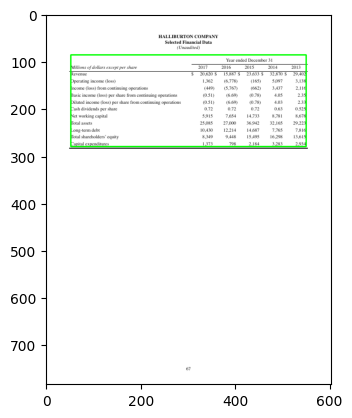

In [ ]:
image_name = final_data.iloc[i,0]
detection = final_data.iloc[i,1]


# load image 
file_name = image_name
pdf_filepath = data_fintabnet_path + "pdf/" + file_name
pdf_page = PdfFileReader(pdf_filepath).getPage(0)
pdf_shape = pdf_page.mediaBox
pdf_height = pdf_shape[3]-pdf_shape[1]
pdf_width = pdf_shape[2]-pdf_shape[0]
converted_images = convert_from_path(pdf_filepath, size=(pdf_width, pdf_height))
img = converted_images[0]
img_np = np.array(img)
# load bbox ground truth 
for table_box in detection:
    tl_x =              (table_box[0])
    tl_y = float(pdf_height) - (table_box[3]) 
    br_x =              (table_box[2])
    br_y = float(pdf_height) - (table_box[1])
    # draw rectangle on image
    cv2.rectangle(img_np, (int(tl_x), int(tl_y)), (int(br_x), int(br_y)), (0, 255, 0), 2)
plt.imshow(img_np)


# pred 

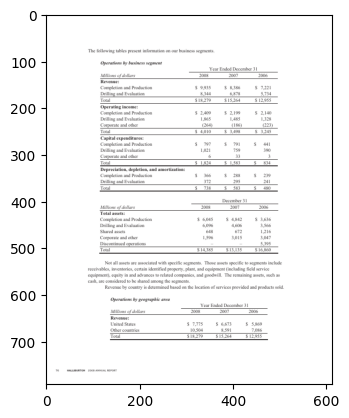

In [6]:
data_detection = json.loads(structure_lines[i])
# table_dict = table_dict_final(i)
file_name= data_detection['filename']
file_name_str = str(file_name[:-4]).replace('/','_')
table_id = data_detection['table_id']
file_name_str = file_name_str + '_' + str(table_id)
pdf_filepath = data_fintabnet_path + "pdf/" + file_name
pdf_page = PdfFileReader(pdf_filepath).getPage(0)
pdf_shape = pdf_page.mediaBox
pdf_height = pdf_shape[3]-pdf_shape[1]
pdf_width = pdf_shape[2]-pdf_shape[0]
converted_images = convert_from_path(pdf_filepath, size=(pdf_width, pdf_height))
img = converted_images[0]
# print(pdf_height, pdf_width)
# ground truth 
table_box = data_detection['bbox']
# print(f'1st : {table_box}')
# print(f'pdf_height {pdf_height}')
tl_x =              (table_box[0])
tl_y = float(pdf_height) - (table_box[3]) 
br_x =              (table_box[2])
br_y = float(pdf_height) - (table_box[1])
plt.imshow(img)